In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from algorithms import *
from plots import *
from utilities import *

## SDRG ALGORITHM INITIALIZATION

In [26]:
# Global variables
M      = 5000
N      = 2048
ZETA   = 1
H0     = 0
DEBUG  = False

N_p = 10
gamma_list = [0.5, 0.93, 1, 1.25, 1.5]
for gamma_0 in gamma_list:
    omega_list, decimations = RandomIsing_SDRG(M, N, gamma_0, H0, J_0=1, zeta=ZETA, n_cores=-1, DEBUG=False)
    save_results(decimations, "decimations", gamma_0, H0, N, M, idx=0)
    save_results(omega_list, "excitations", gamma_0, H0, N, M, idx=0)


STARTED STRONG-DISORDER RG ALGORITHM FOR ISING CHAIN (GAMMA0=0.5 - H0=0 - N=2048 - M=5000)
---Executing SD renormalization algorithm on chain #0---
---Executing SD renormalization algorithm on chain #1---
---Executing SD renormalization algorithm on chain #2---
---Executing SD renormalization algorithm on chain #3---
---Executing SD renormalization algorithm on chain #4---
---Executing SD renormalization algorithm on chain #5---
---Executing SD renormalization algorithm on chain #6---
---Executing SD renormalization algorithm on chain #7---
---Executing SD renormalization algorithm on chain #8---
---Executing SD renormalization algorithm on chain #9---
---Executing SD renormalization algorithm on chain #10---
---Executing SD renormalization algorithm on chain #11---
---Executing SD renormalization algorithm on chain #12---
---Executing SD renormalization algorithm on chain #13---
---Executing SD renormalization algorithm on chain #14---


KeyboardInterrupt: 

Estimation of the cross-over region position:

In [ ]:
M     = 100
N     = 2048
ZETA  = 1
H0    = np.exp([-3*k for k in range(2, 6)])

Np = 15
interpol = np.array([np.sqrt(k) / np.sqrt(Np) for k in range(0, Np+1)])
interpol = np.concatenate([0.5*interpol, 1 - interpol[::-1]*0.5])
gamma_list = 0.85 + interpol*(1.05-0.85)

#plt.scatter(gamma_list, [1]*gamma_list.shape[0])
for h0, gamma0 in product(H0, gamma_list):
    omega_list, decimations = RandomIsing_SDRG(M, N, gamma0, h0, J_0=1, zeta=ZETA, n_cores=3, DEBUG=False)
    save_results(omega_list, "excitations", gamma0, h0, N, M, 0)
    

Scaling behaviour in vicinity of the IDFP

In [ ]:
M      = 3
N      = 128
ZETA   = 1
H0     = 0
GAMMA0 = 0.93

omega_list, decimations, mm = RandomIsing_SDRG(M, N, GAMMA0, H0, 1, ZETA, 1)


STARTED STRONG-DISORDER RG ALGORITHM FOR ISING CHAIN (GAMMA0=0.93 - H0=0 - N=128 - M=3)
---Executing SD renormalization algorithm on chain #0---
---SDRG algorithm executed on chain #0---
---Executing SD renormalization algorithm on chain #1---
---SDRG algorithm executed on chain #1---
---Executing SD renormalization algorithm on chain #2---
---SDRG algorithm executed on chain #2---

SDRG ALGORITHM EXECUTED WITH TIME 0.09291291236877441 (s).


0.0005345557638375992

In [ ]:
from glob import glob

t = glob("crossover-region/*")
len(t)

120

## SDRG Fixed points

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/decimations/*


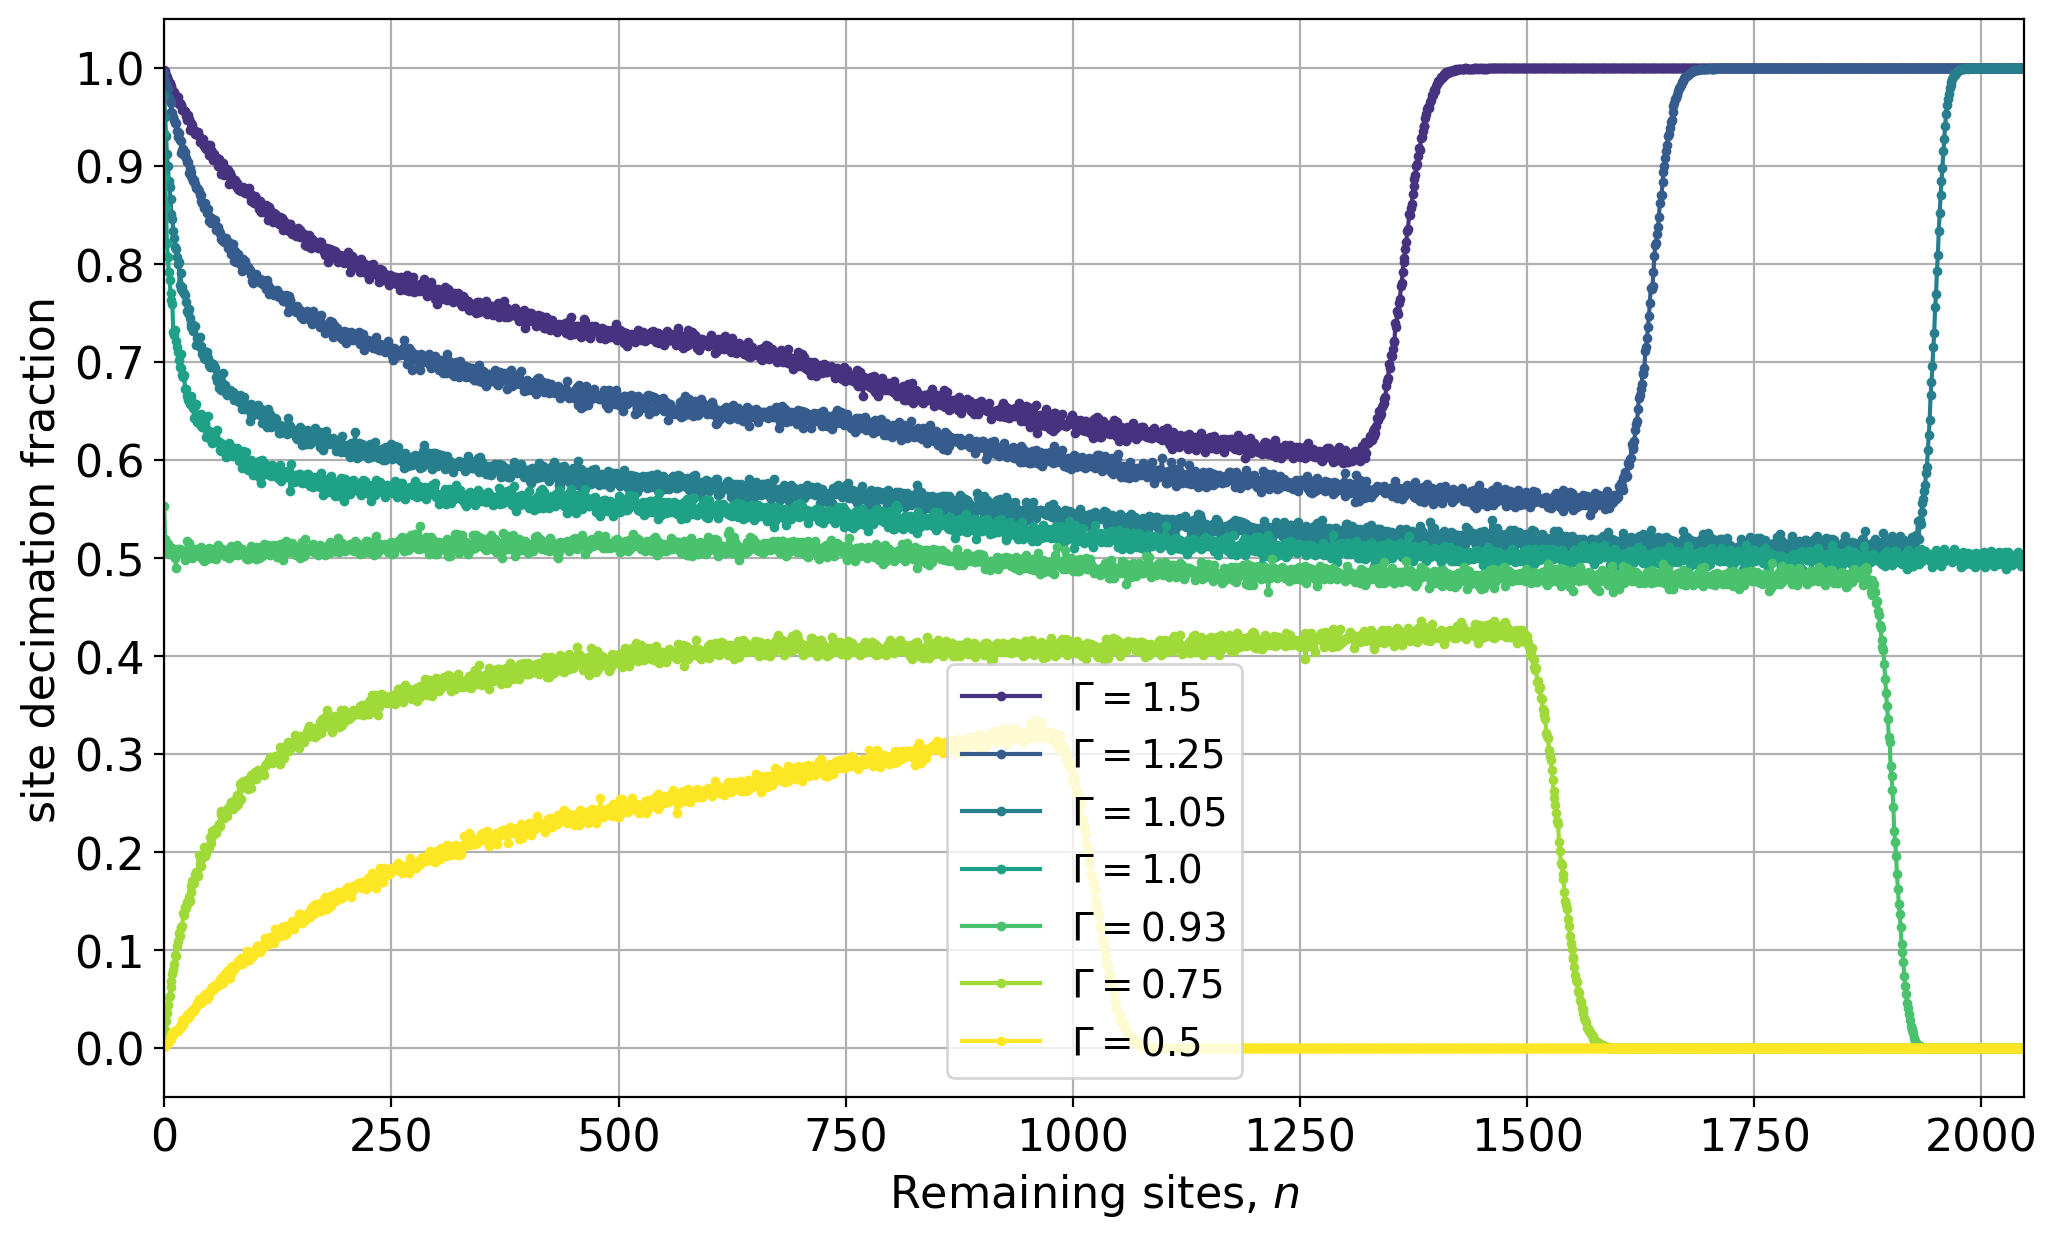

In [4]:
N = 2048
H0 = 0

decimations_res, gamma_list, _ = read_results("decimations")
plot_results("decimations", decimations_res[:-1, :], N-1, gamma_list, H0)

## Properties of the RG-flow

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/propRGflow/decimations/*


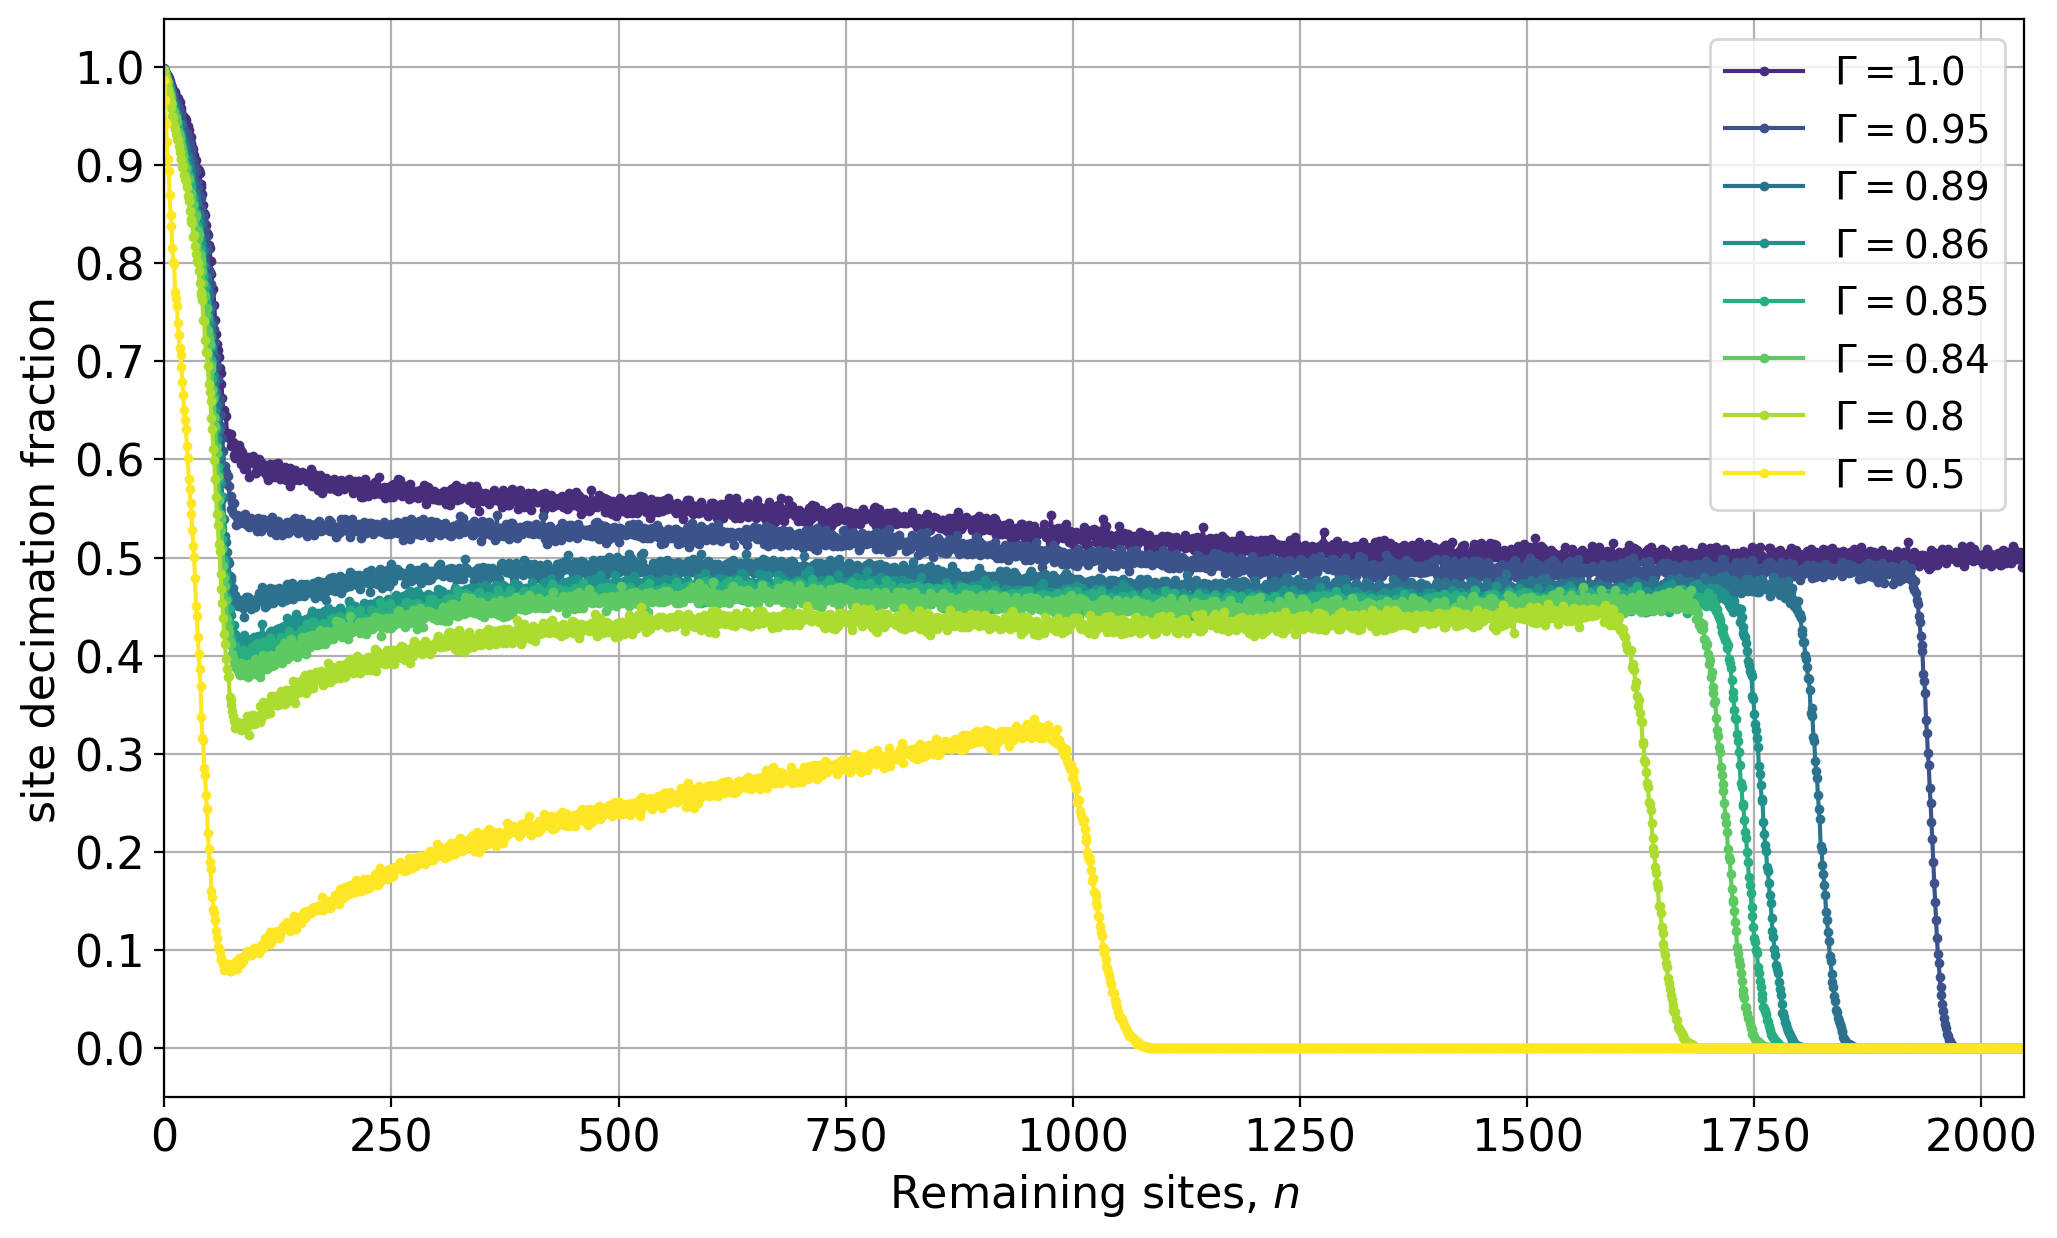

In [5]:
decimations_res_h0, gamma_list, h_list = read_results("propRGflow/decimations")
mask = h_list != 0
plot_results("decimations", decimations_res_h0[:-1, mask], N-1, gamma_list[mask])

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/propRGflow/decimations/*


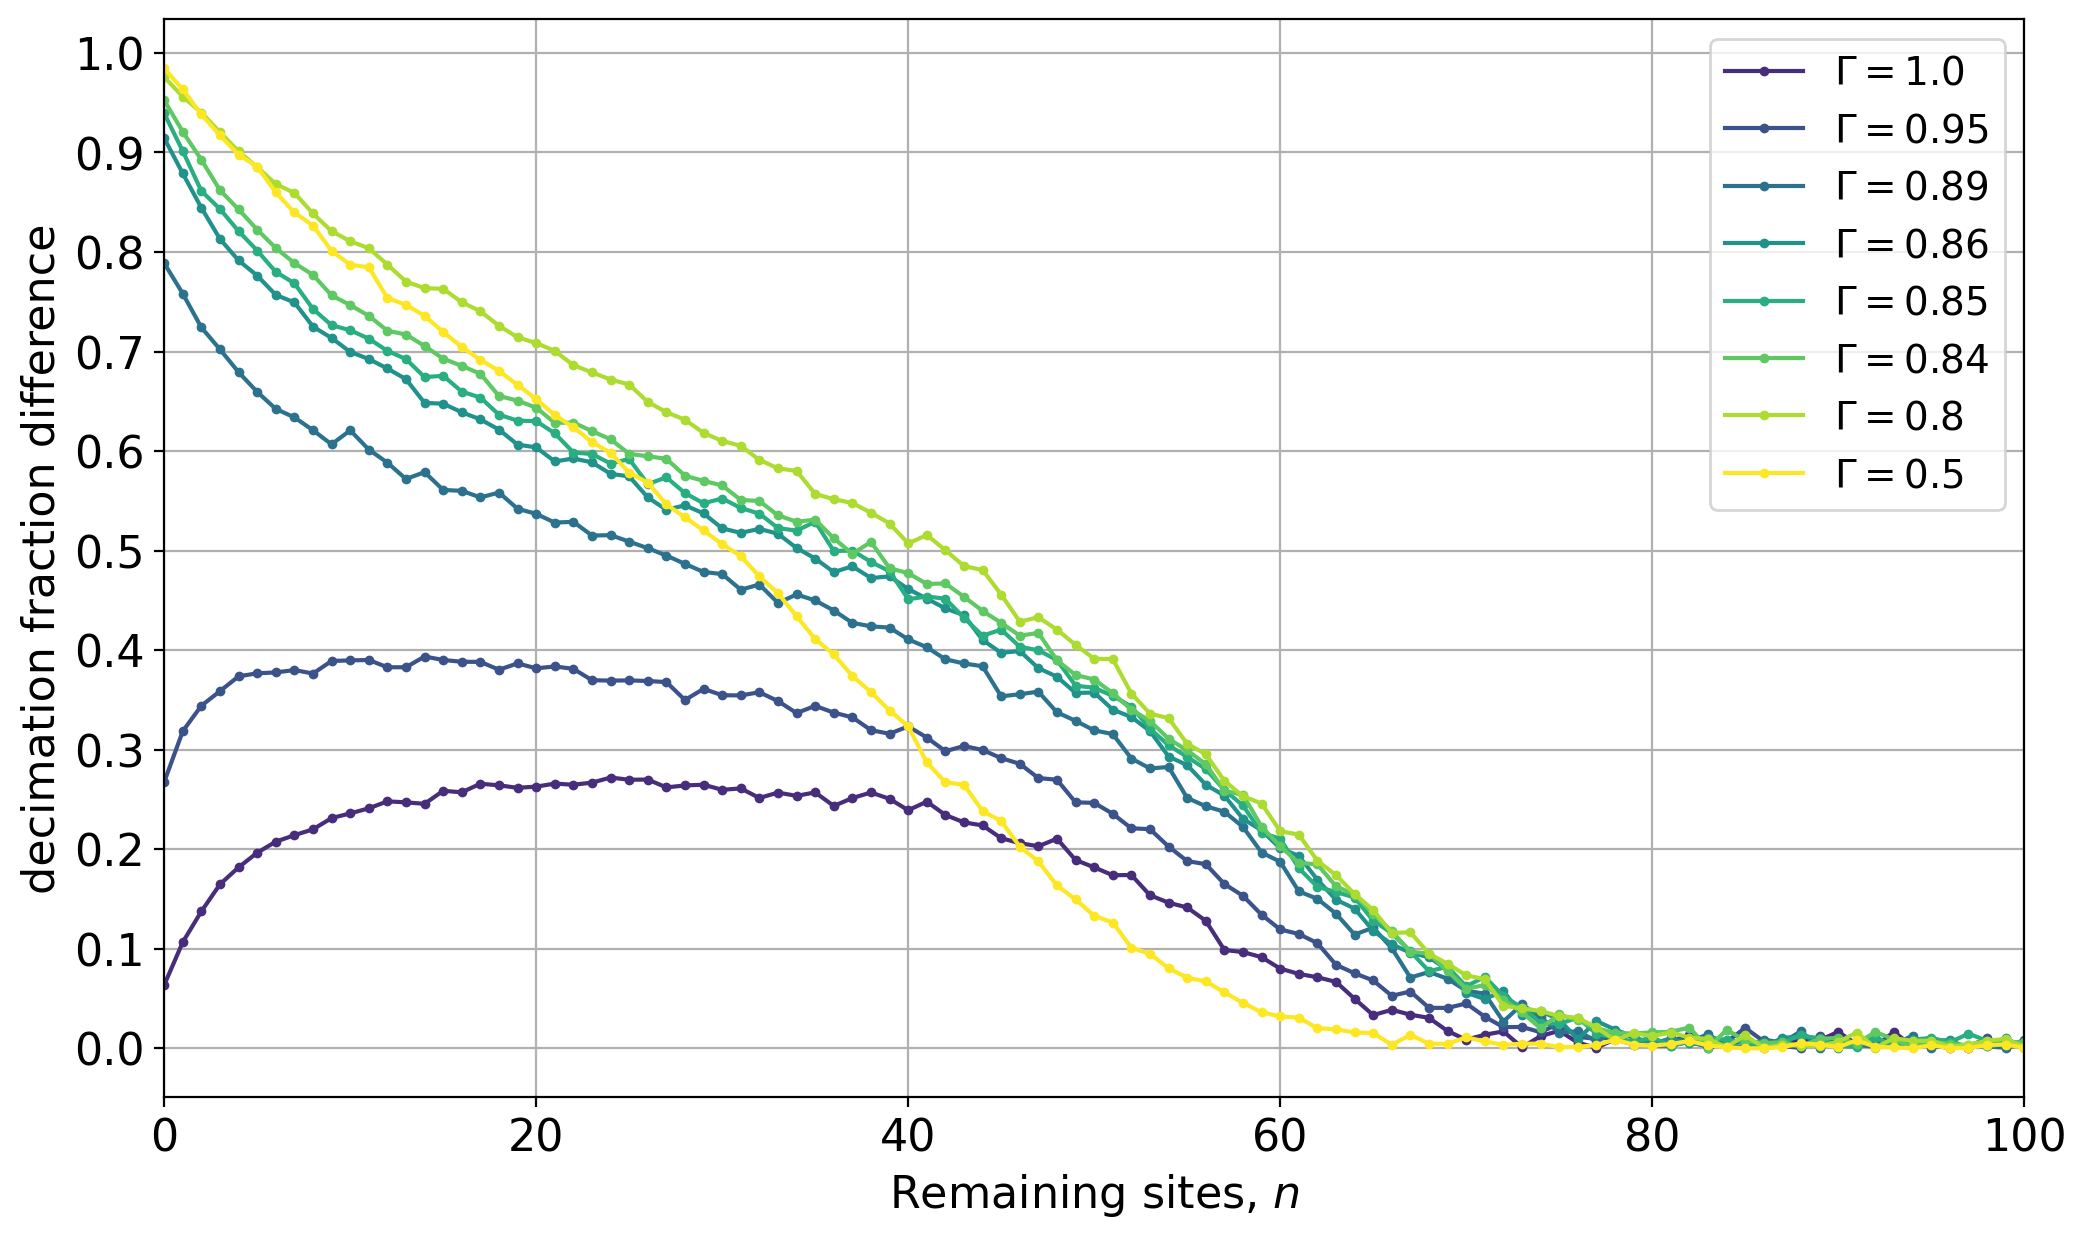

In [45]:
# There are only 2 values of h0 
decimations, gamma_list, h_list = read_results("propRGflow/decimations")

sorting = np.argsort(gamma_list)

# decimations matrix columns are sorted in such a way that columns with same gamma are close to each other (even and odd idx)
sorted_decim = decimations[:, sorting]
sorted_gamma = gamma_list[sorting]

# differences are given by subtracting elements at close columns
plot_results("decimations", np.abs(sorted_decim[:-1, 0::2] - sorted_decim[:-1, 1::2]), N-1, sorted_gamma[0::2], x_lim=100, y_label="decimation fraction difference")

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/propRGflow/excitations/*


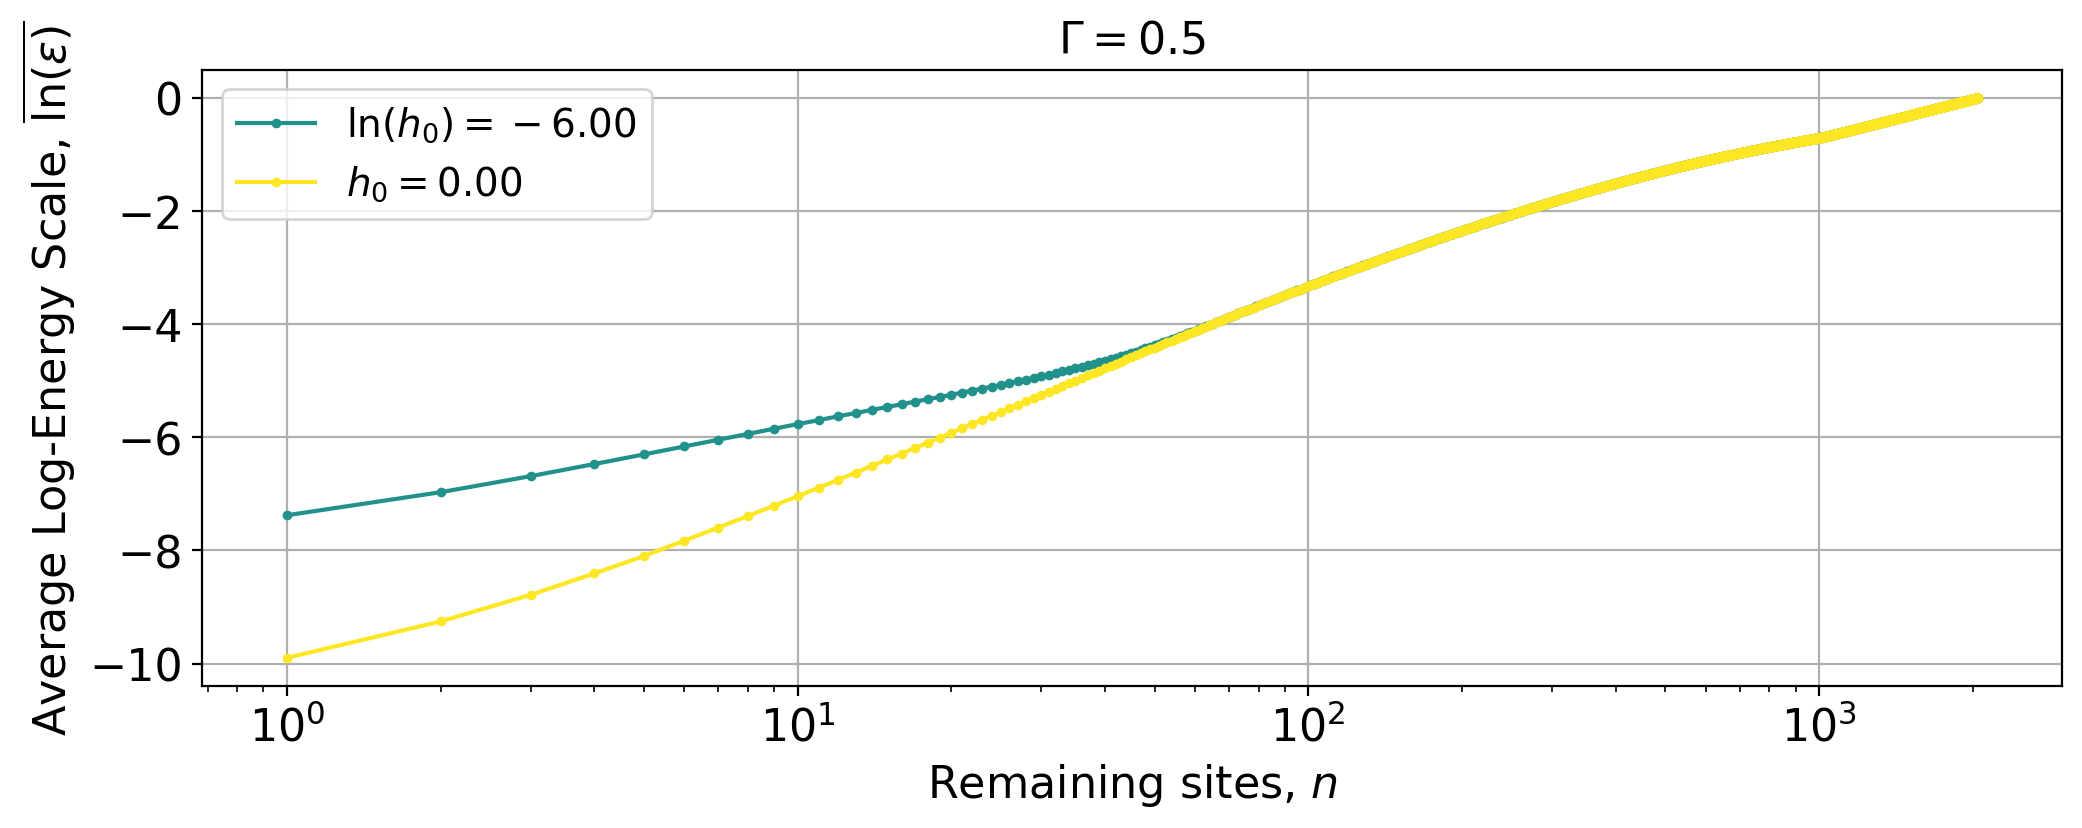

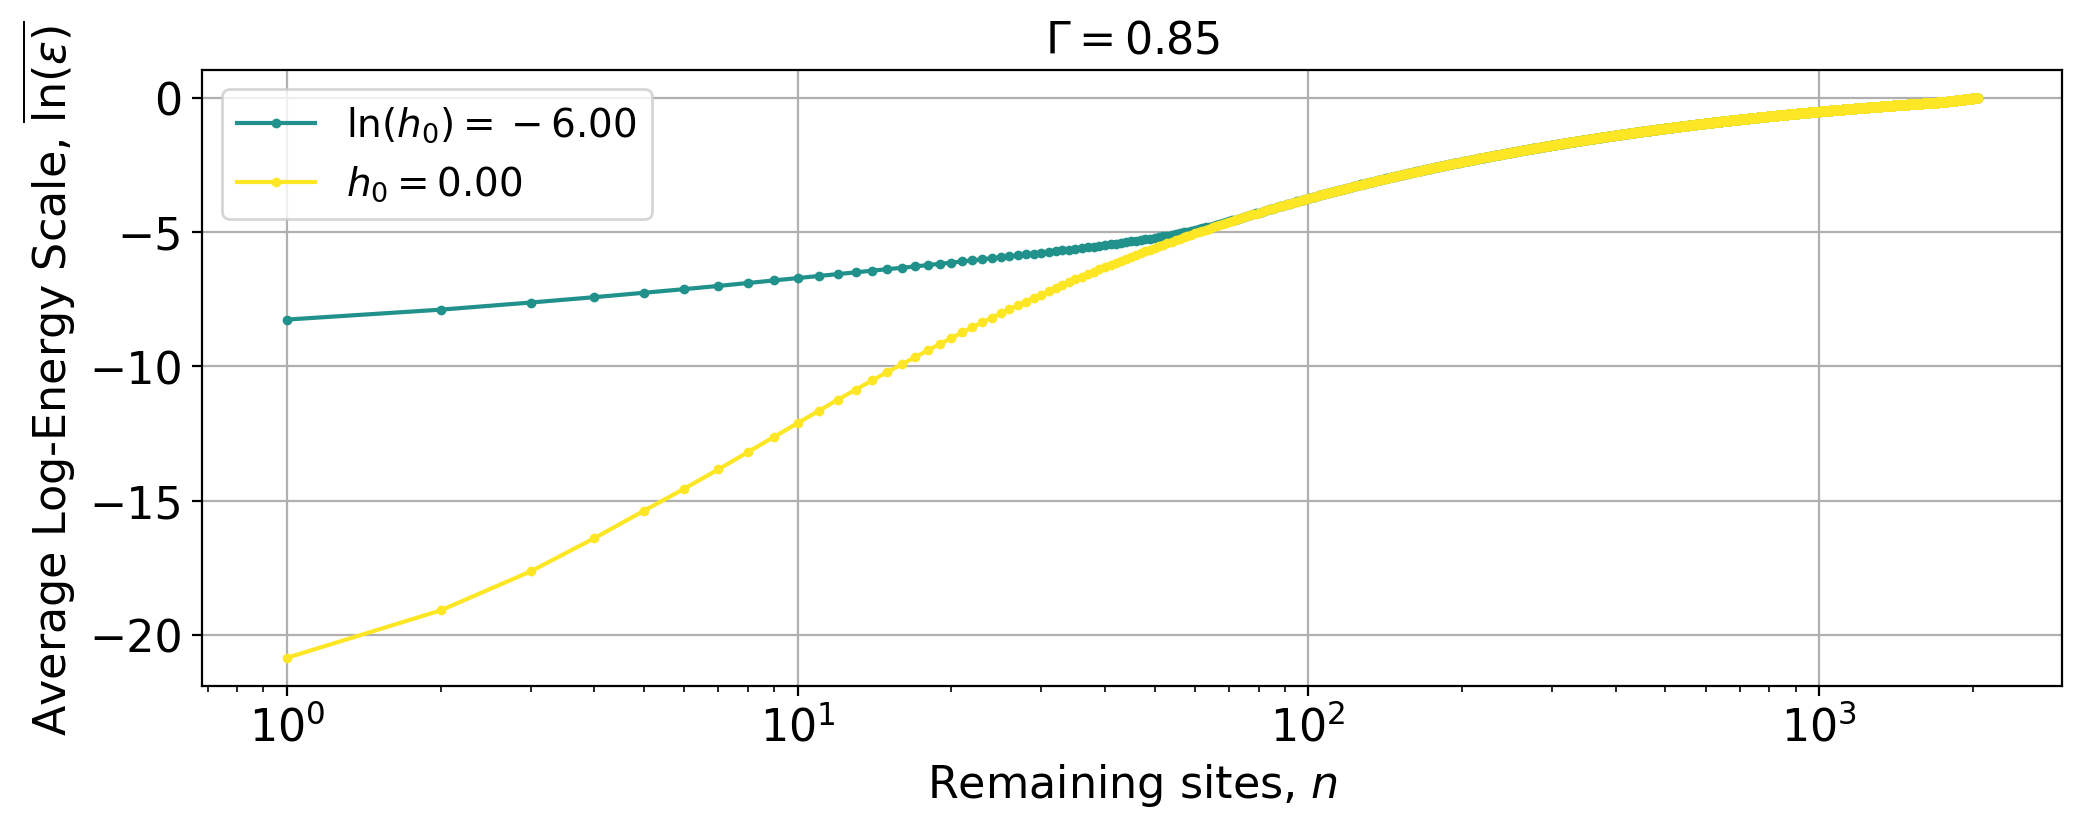

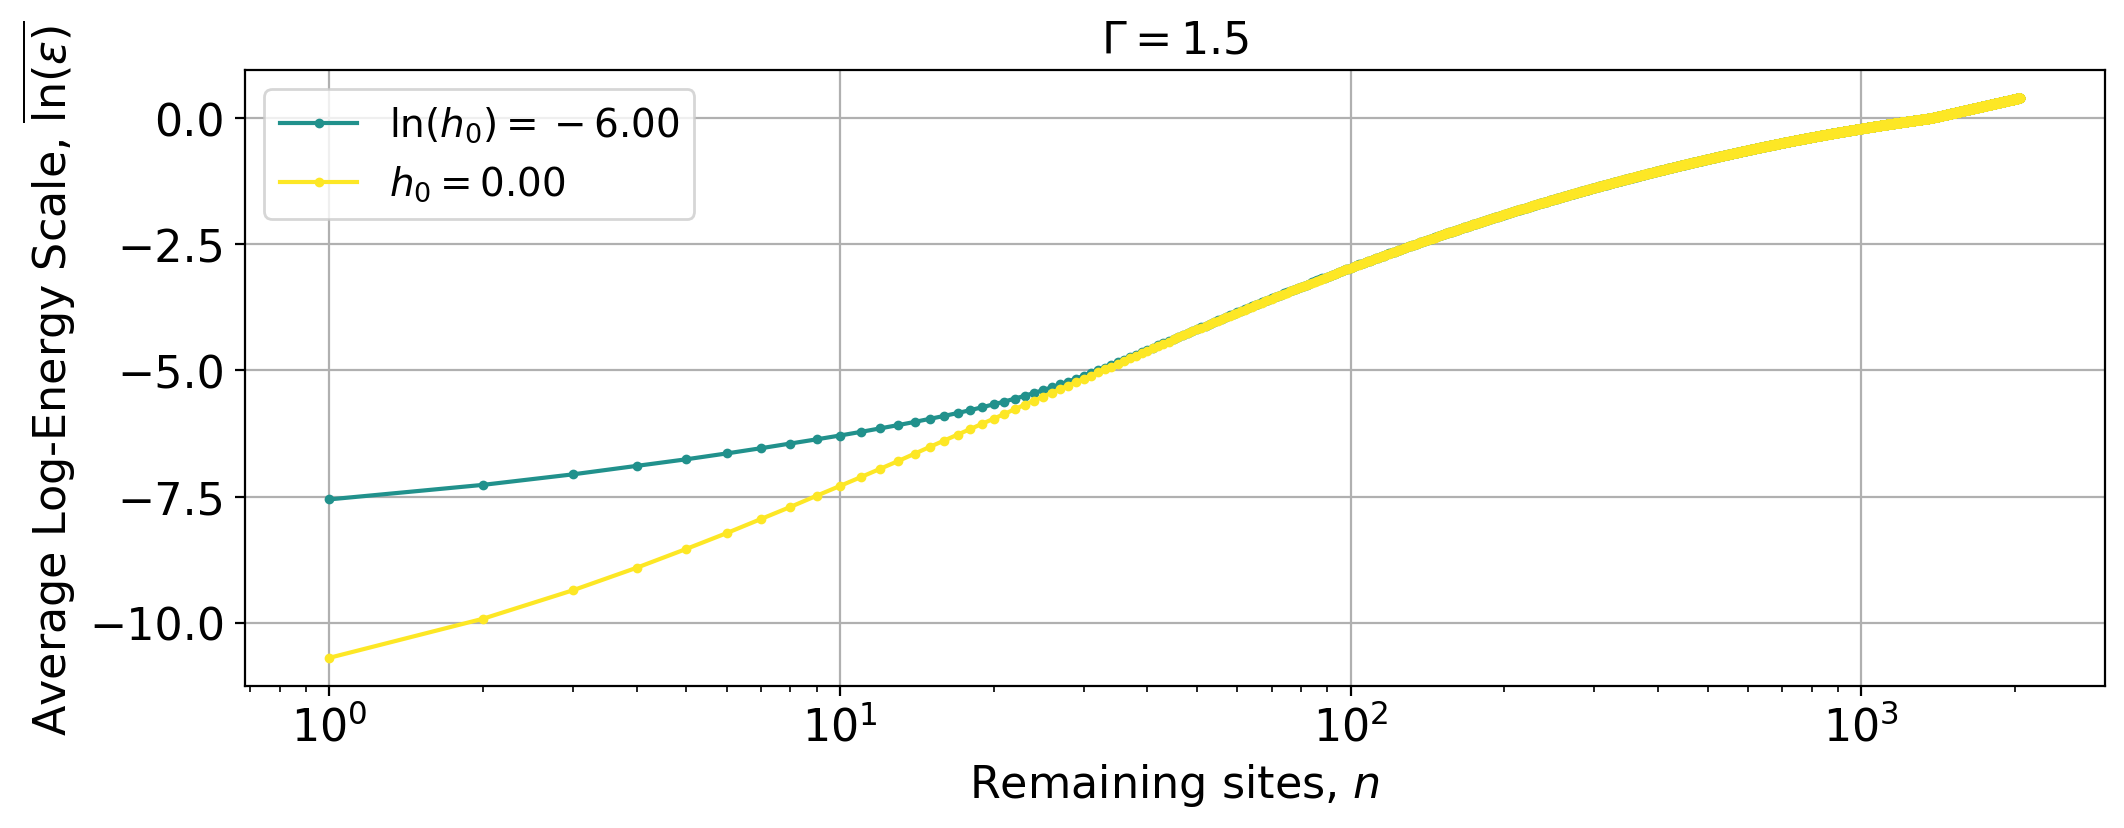

In [46]:
excitations, gamma_list, h_list= read_results("propRGflow/excitations")
for gamma in [0.5, 0.85, 1.5]:
    mask = gamma_list == gamma
    plot_results("excitations", excitations[1:, mask], N-1, h_list[mask], title=fr"$\Gamma=${gamma}", y_size=4)

## Estimates for the position of the cross-over region

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester_3/Quantum_Info_and_Computing/QIAC2-project/crossover-region2/*


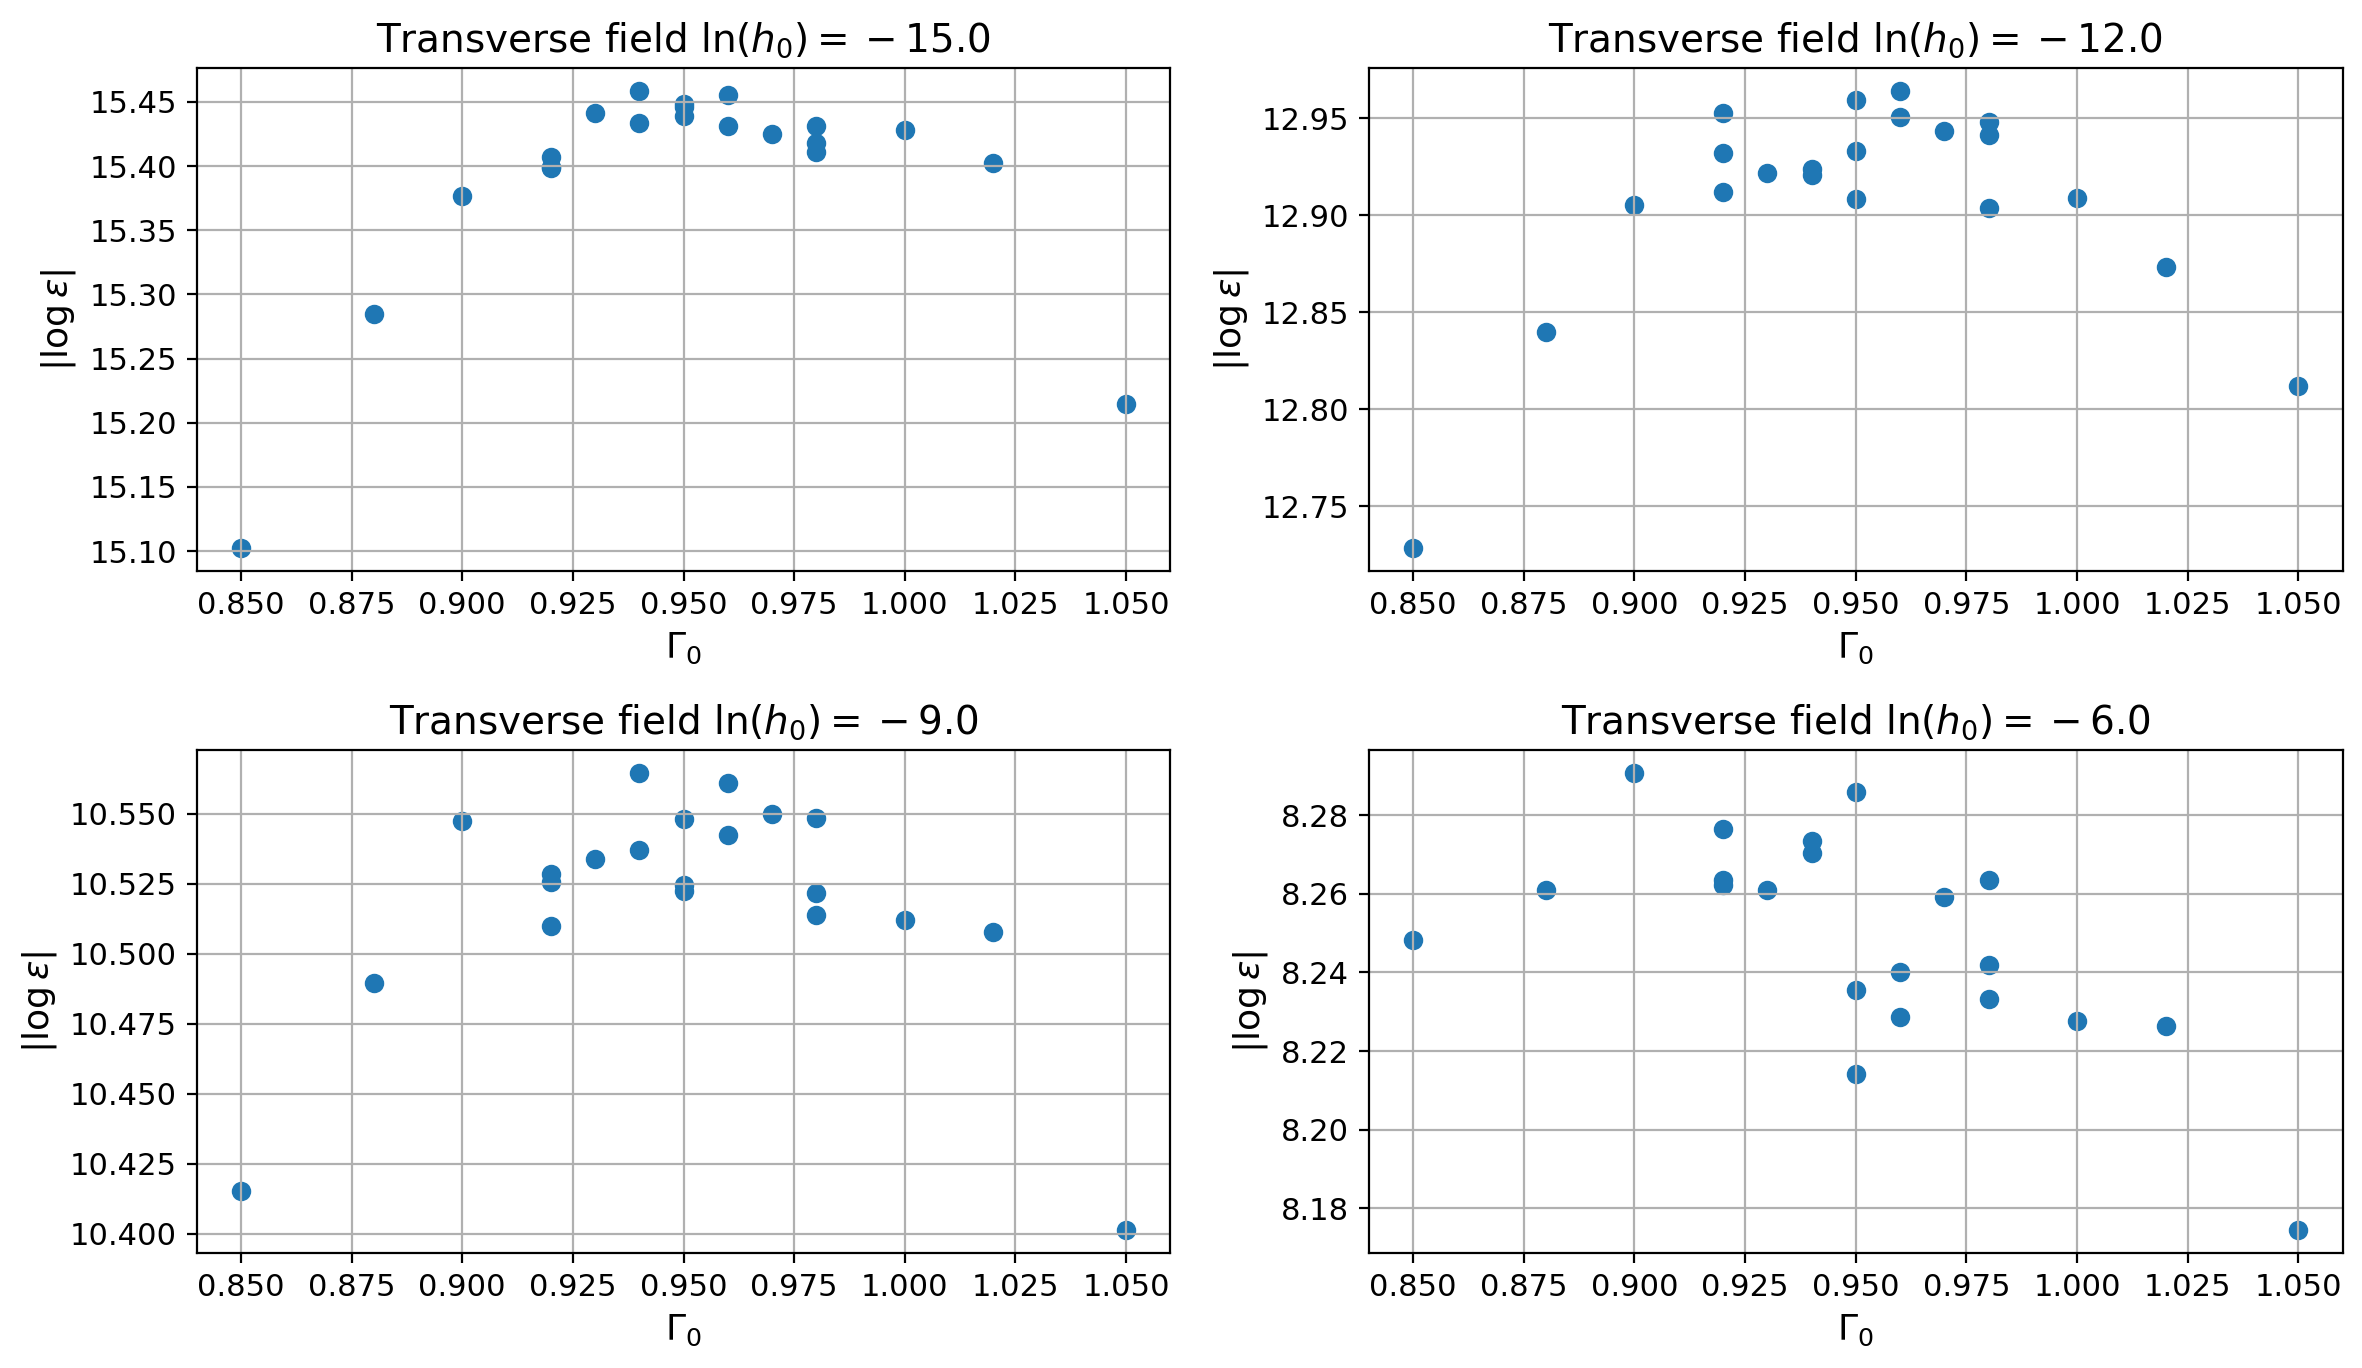

In [ ]:
'''
----------------------------------------------------------
Values of gamma0 and H0 are generated with:

    H0    = np.exp([-3*k for k in range(2, 6)])

    interpol = np.array([np.sqrt(k) / np.sqrt(Np) for k in range(0, Np+1)])
    interpol = np.concatenate([0.5*interpol, 1 - interpol[::-1]*0.5])
    gamma_list = 0.88 + interpol*(1.02-0.88)
----------------------------------------------------------
'''

omega, gamma, h = read_results("crossover-region2")
plot_critial_position(omega[-2, :], gamma, h)

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/relevScaling/excitations/*


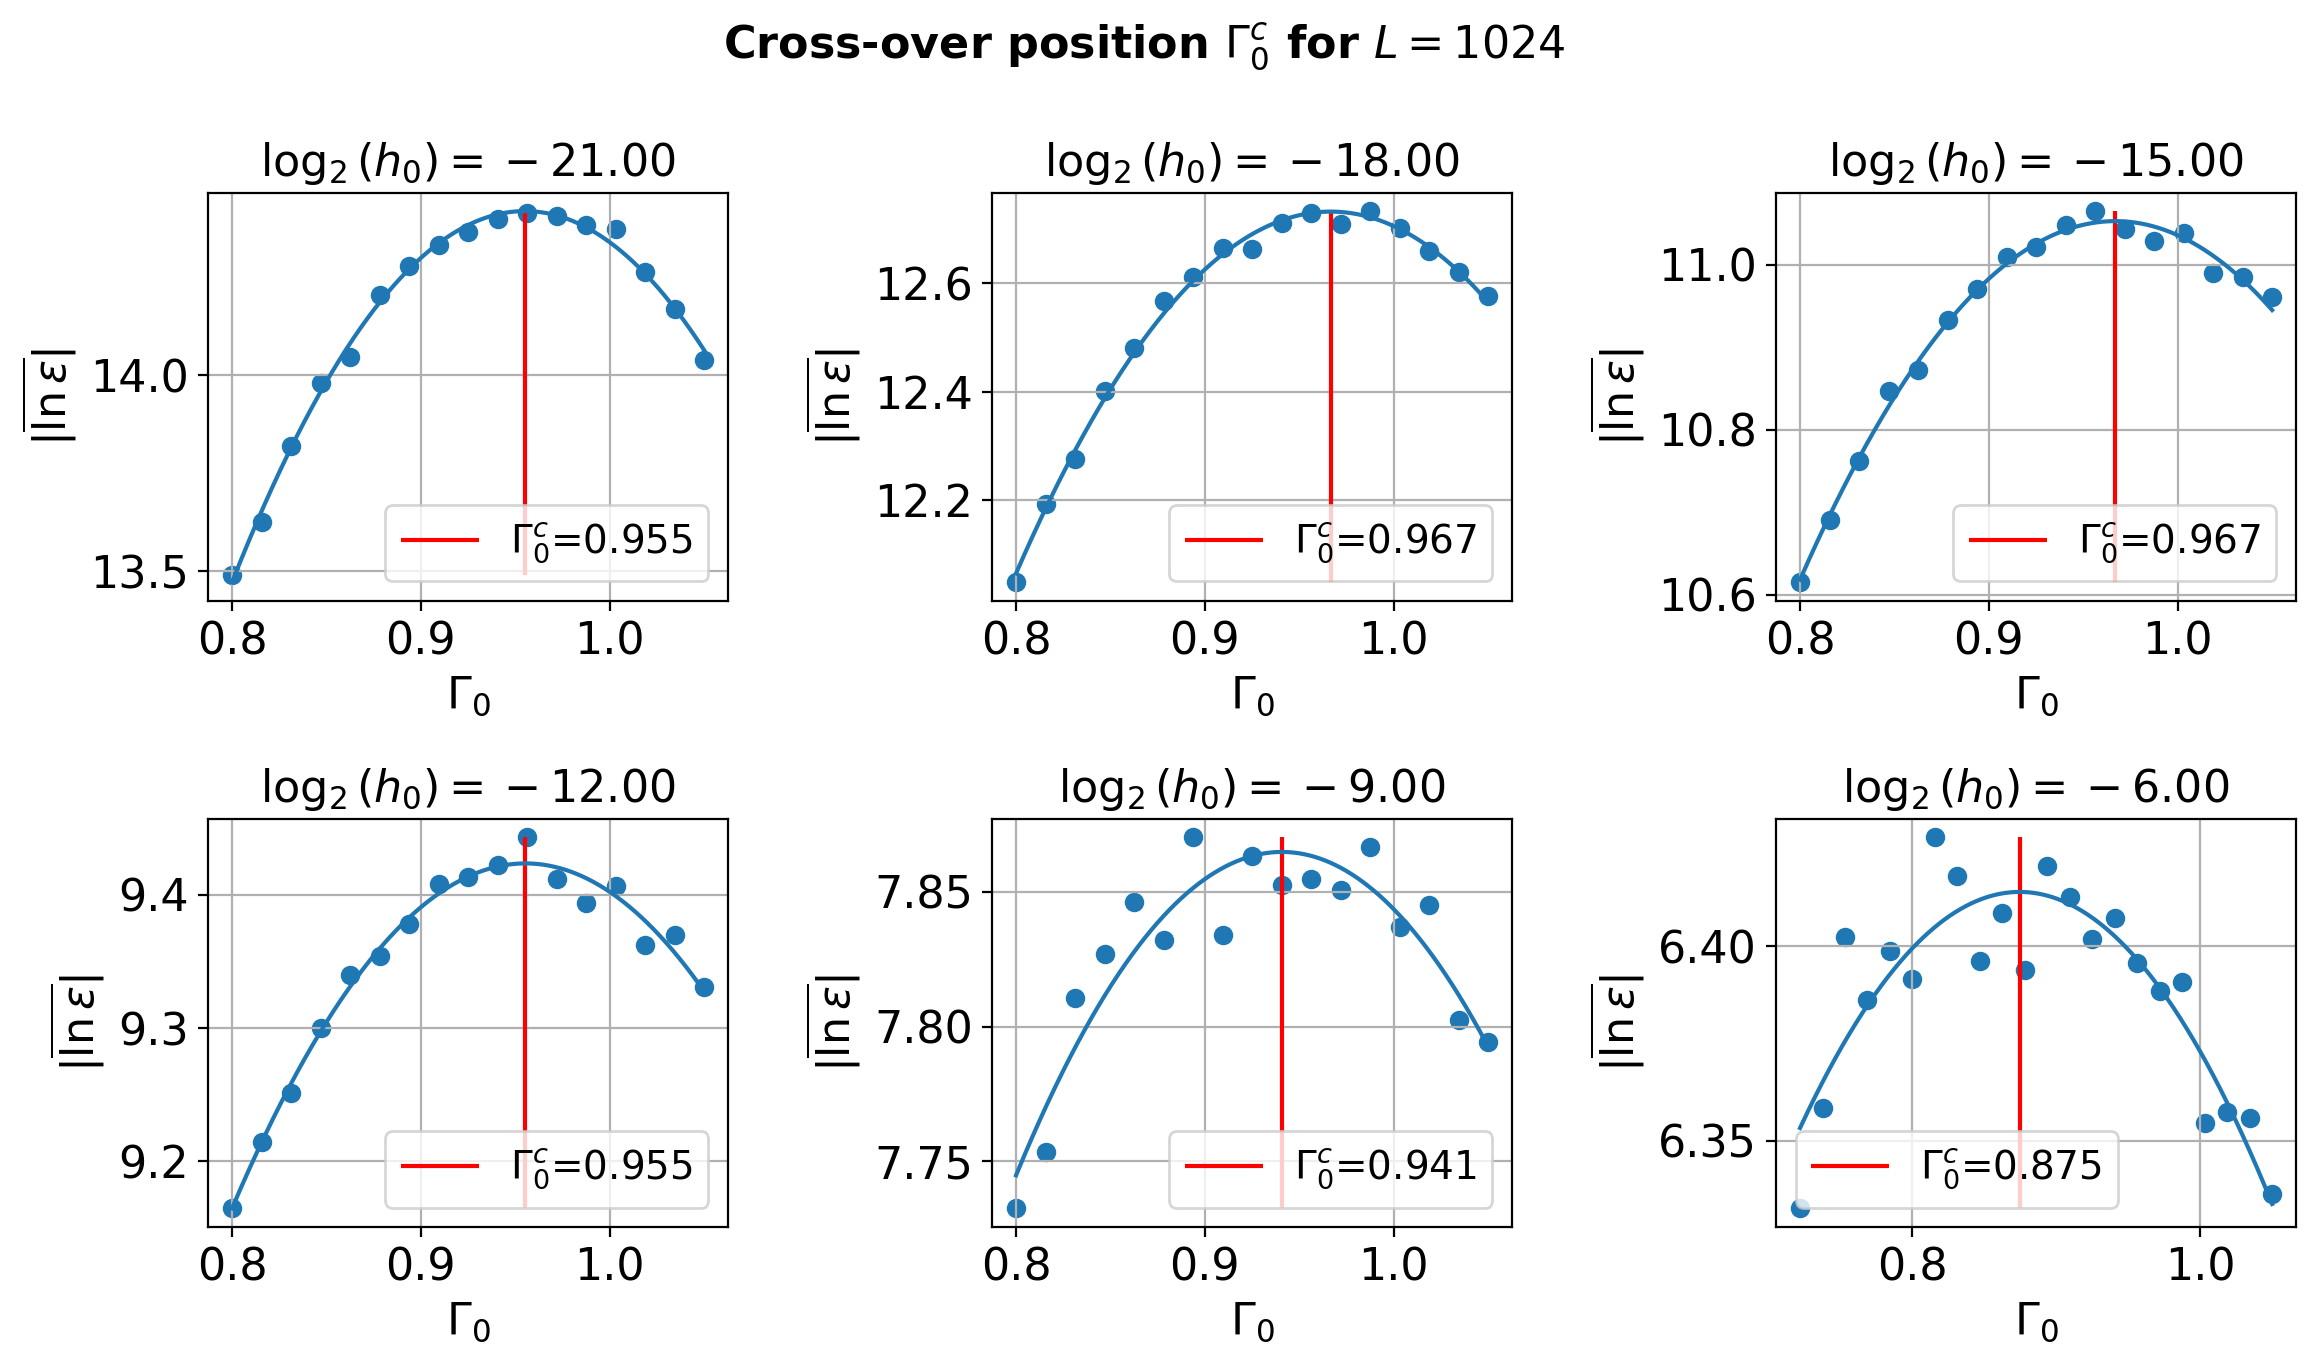

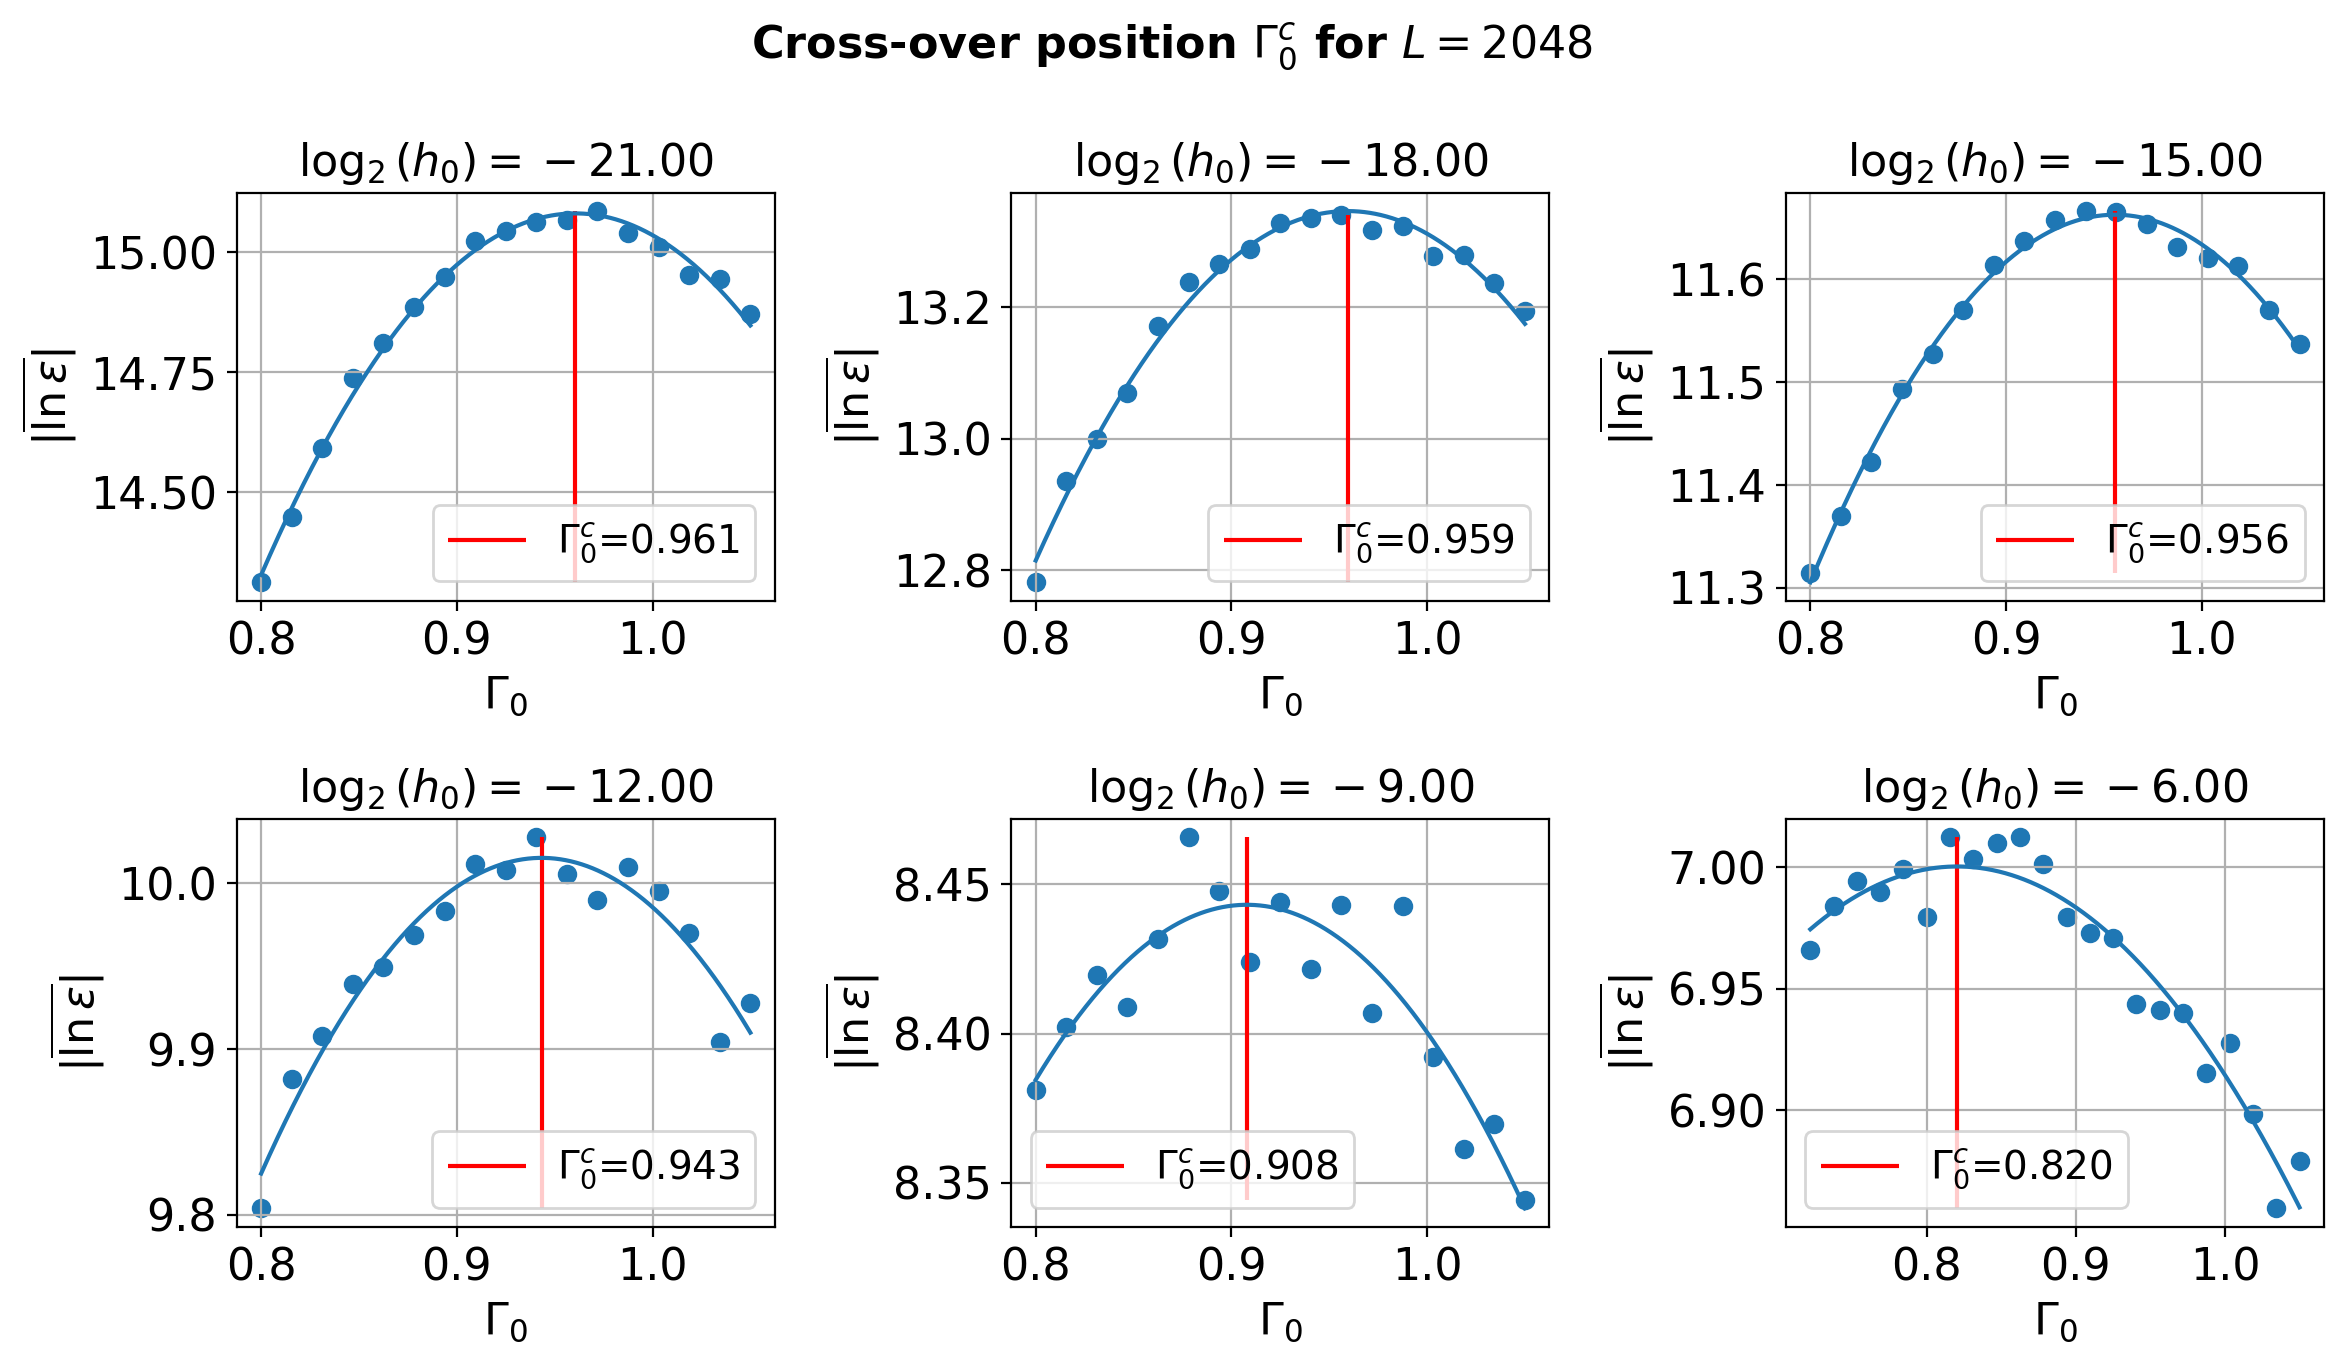

In [9]:
'''
M      = int(input("Input number of samples (M):\n"))
N      = [2**n for n in range(10, 12)] # IMPORTANT: after this run change N extrema into 12, 14!!!
ZETA   = 1
H0     = [2**(-3*exp) for exp in range(2, 8)]
GAMMA0 = [0.8 + (e/16)*(1.05-0.8) for e in range(0, 17)]

combinations = list(product(GAMMA0, H0, N))
total_c = len(combinations)
'''

critical_positions = {}
curvature_radius   = {}

final_values = read_final_values(dir_name="relevScaling/excitations", save_gamma=True)
critical_positions[1024], curvature_radius[1024] = plot_critical_positions(final_values, L = 1024, fit_parabolas=True)
critical_positions[2048], curvature_radius[2048] = plot_critical_positions(final_values, L = 2048, fit_parabolas=True)

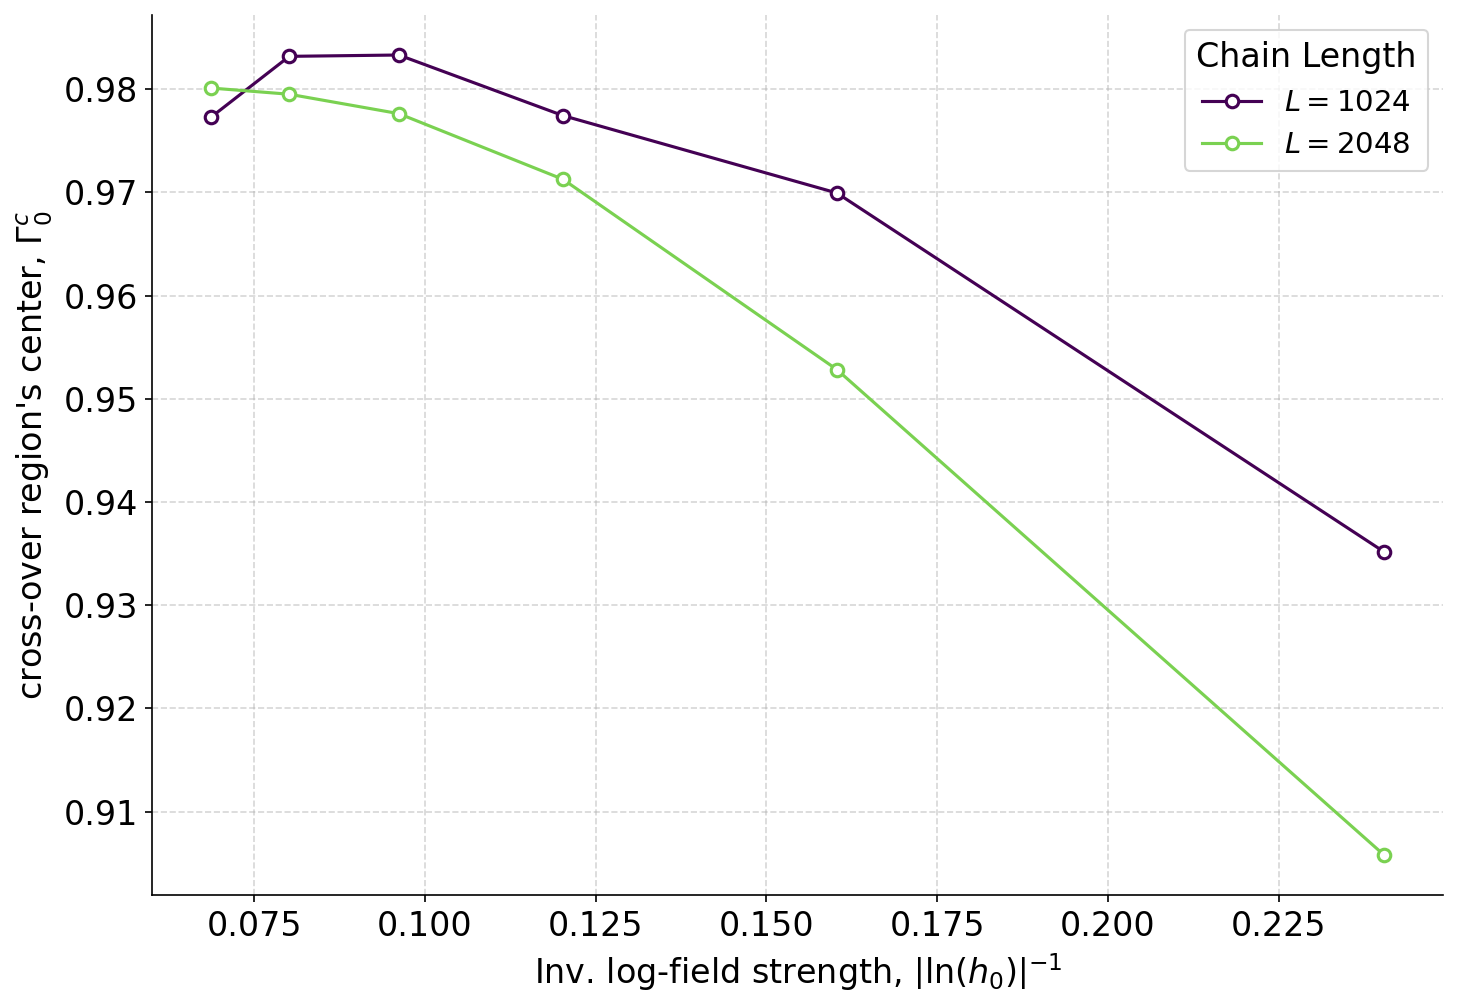

In [48]:
plot_critical_lines(critical_positions)

Chi squared for L=1024: 6.618e-05
Chi squared for L=2048: 1.861e-04


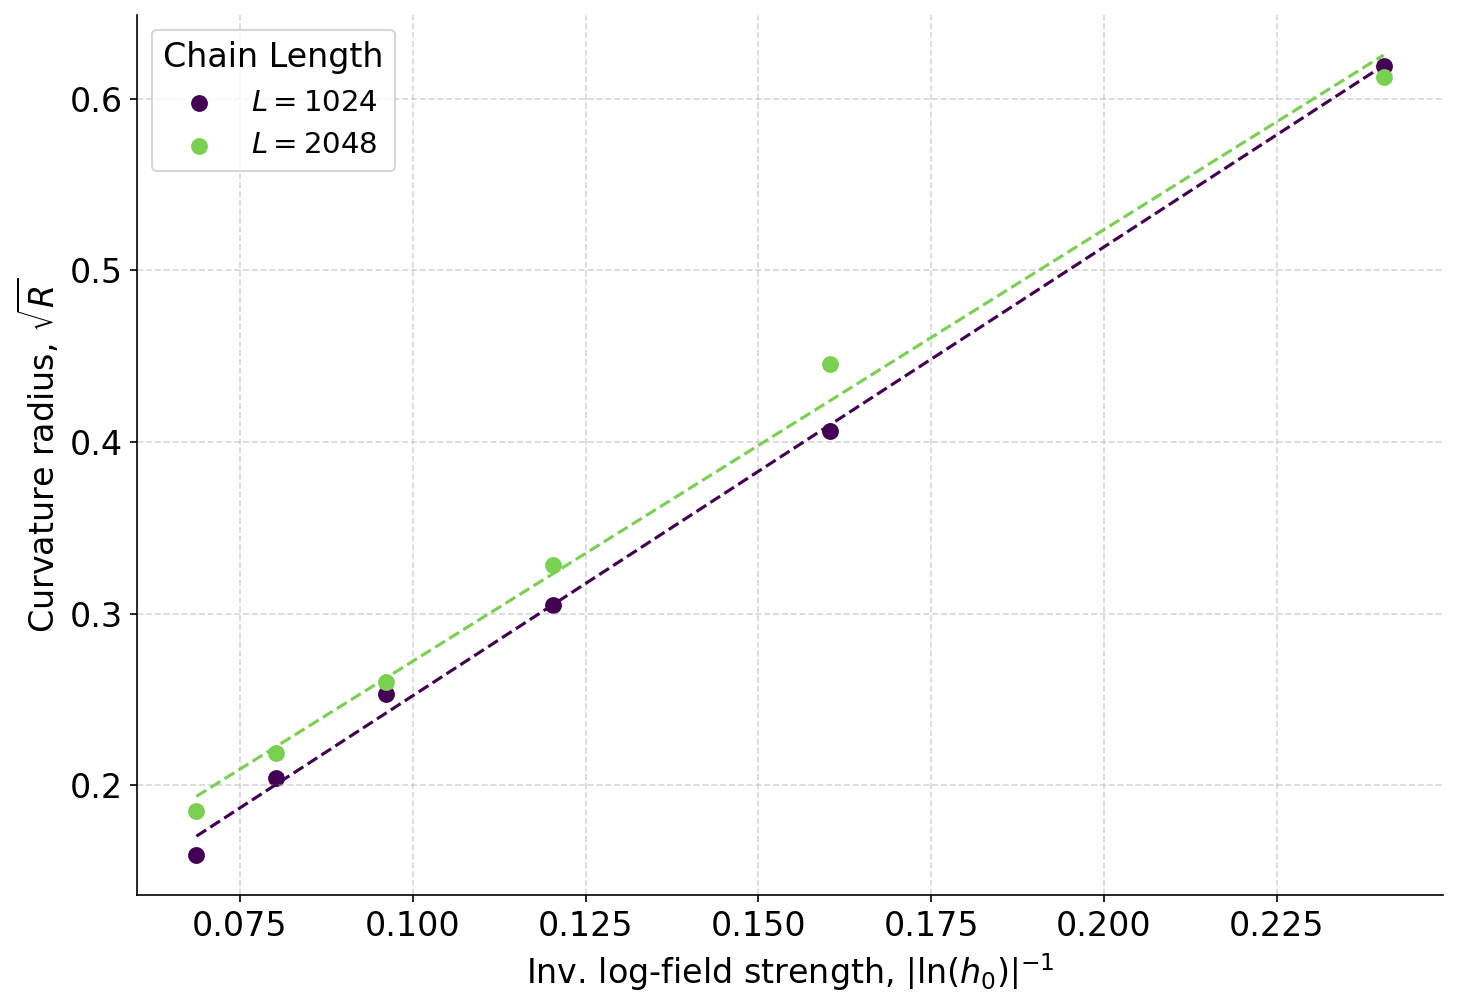

In [38]:
plot_critical_lines(curvature_radius, ylabel=r"Curvature radius, $\sqrt{R}$", square_y=True, linear_fit=True)

## analysis along the line $\Gamma_0^c= 0.93$

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/log_gaps_at_gamma0C/*


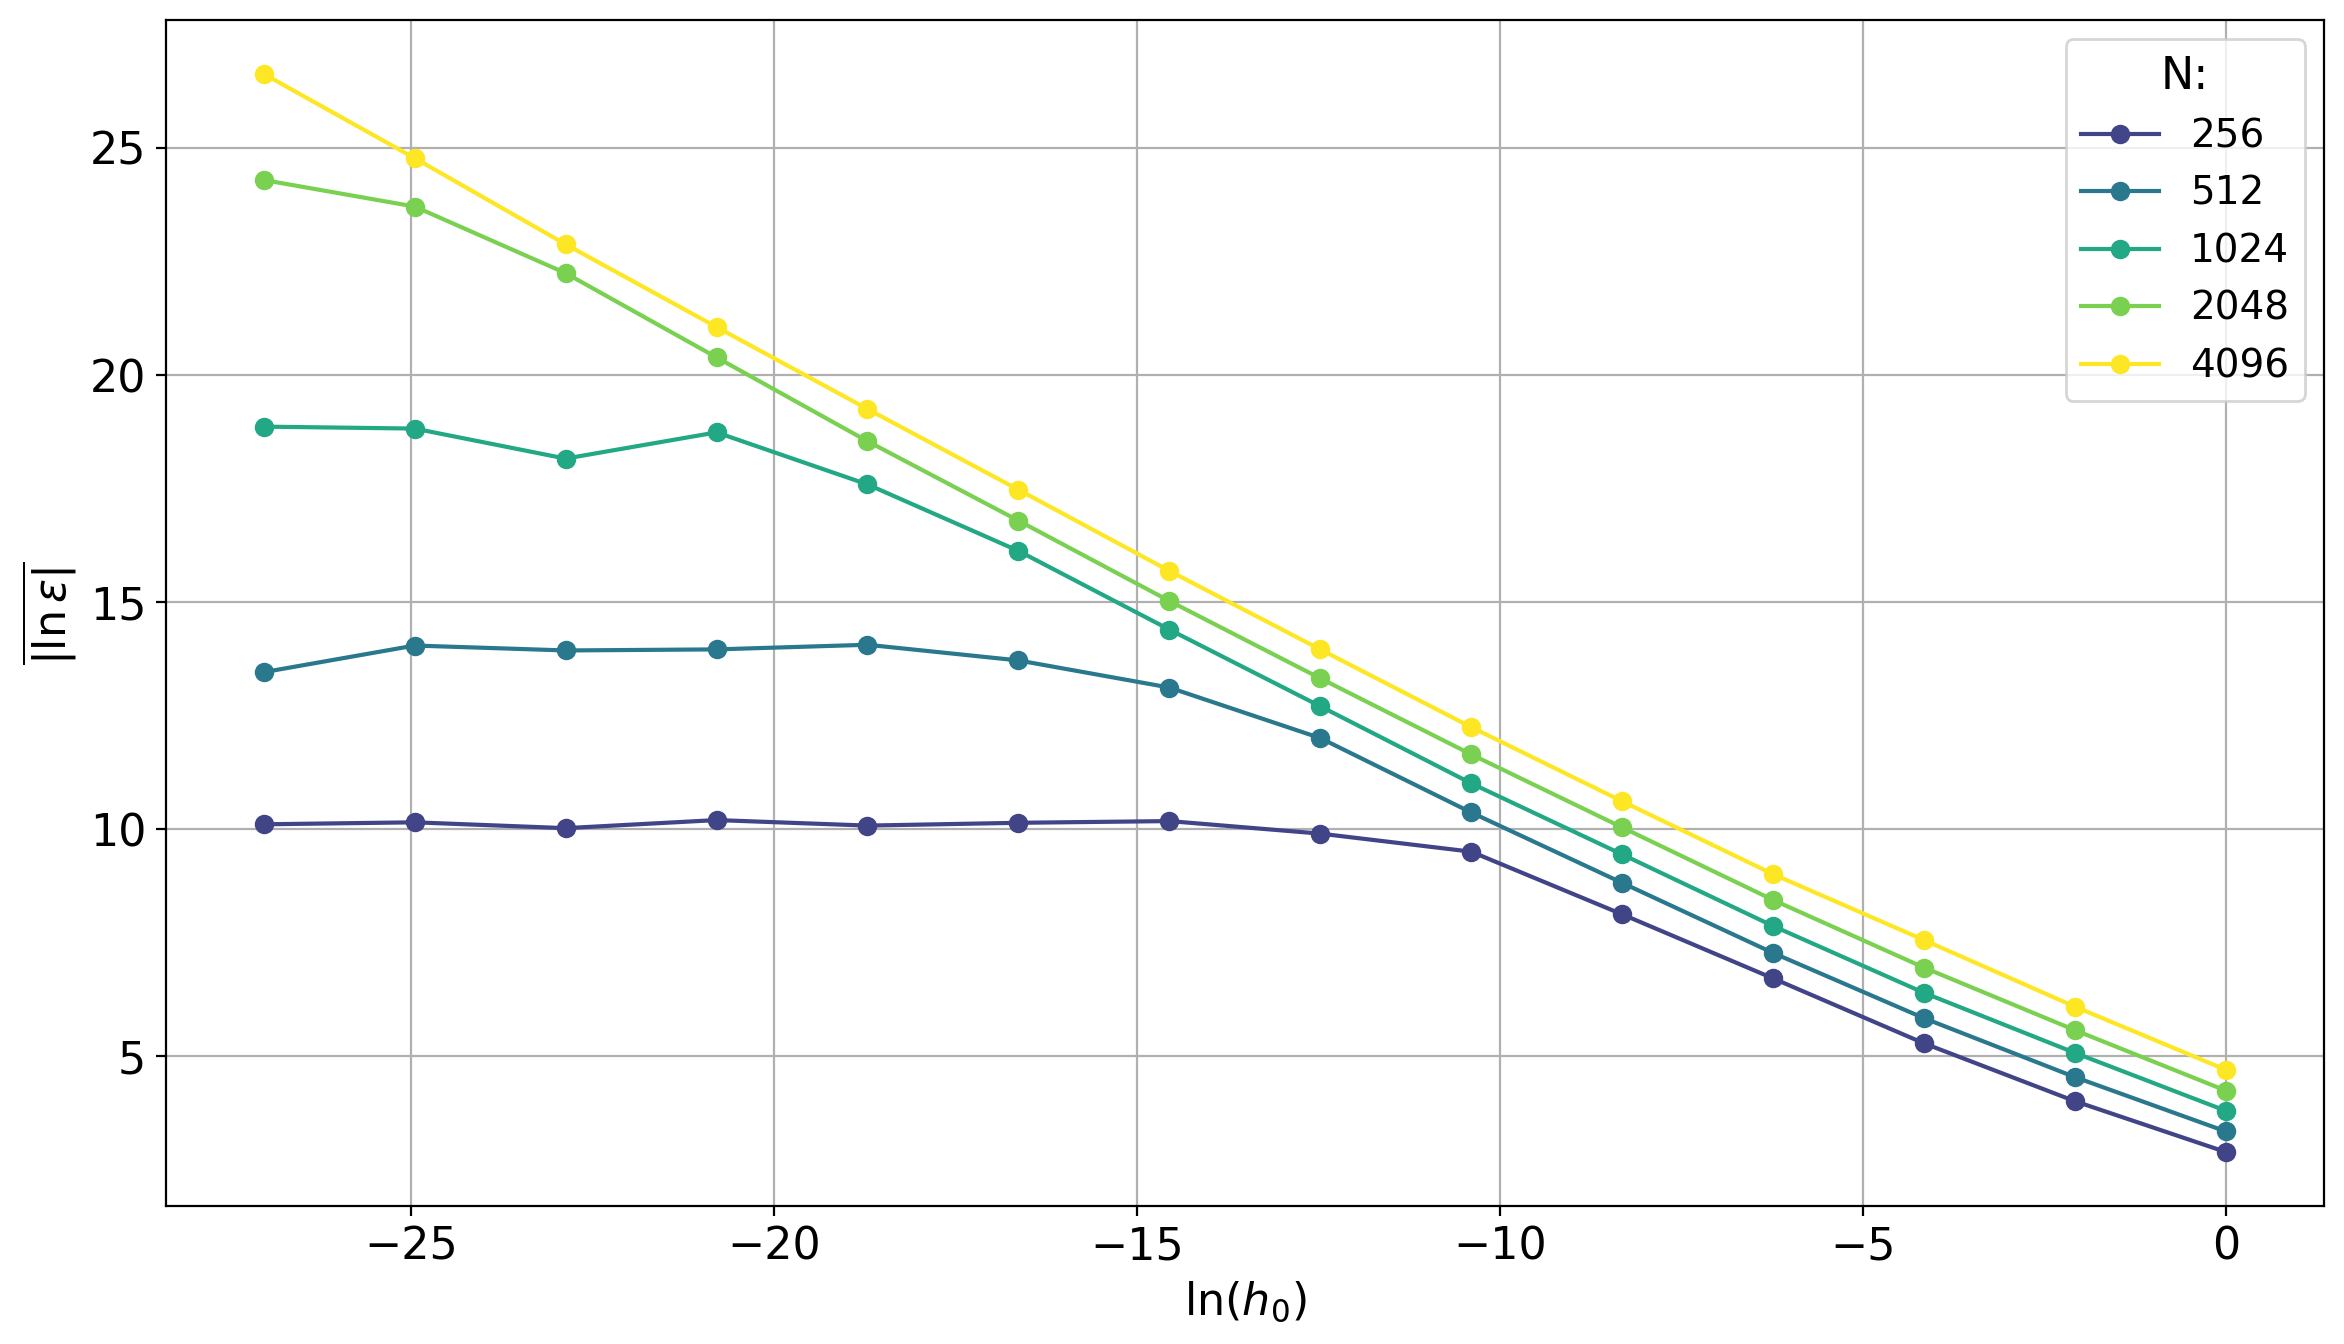

In [43]:
results = read_final_values("log_gaps_at_gamma0C")
plot_analysics_at_critical_point(results, log_abs=True, ylabel=r"$\overline{|\ln \varepsilon|}$")

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester 3/Quantum_Info_and_Computing/QIAC2-project/mm_at_gamma0C/*


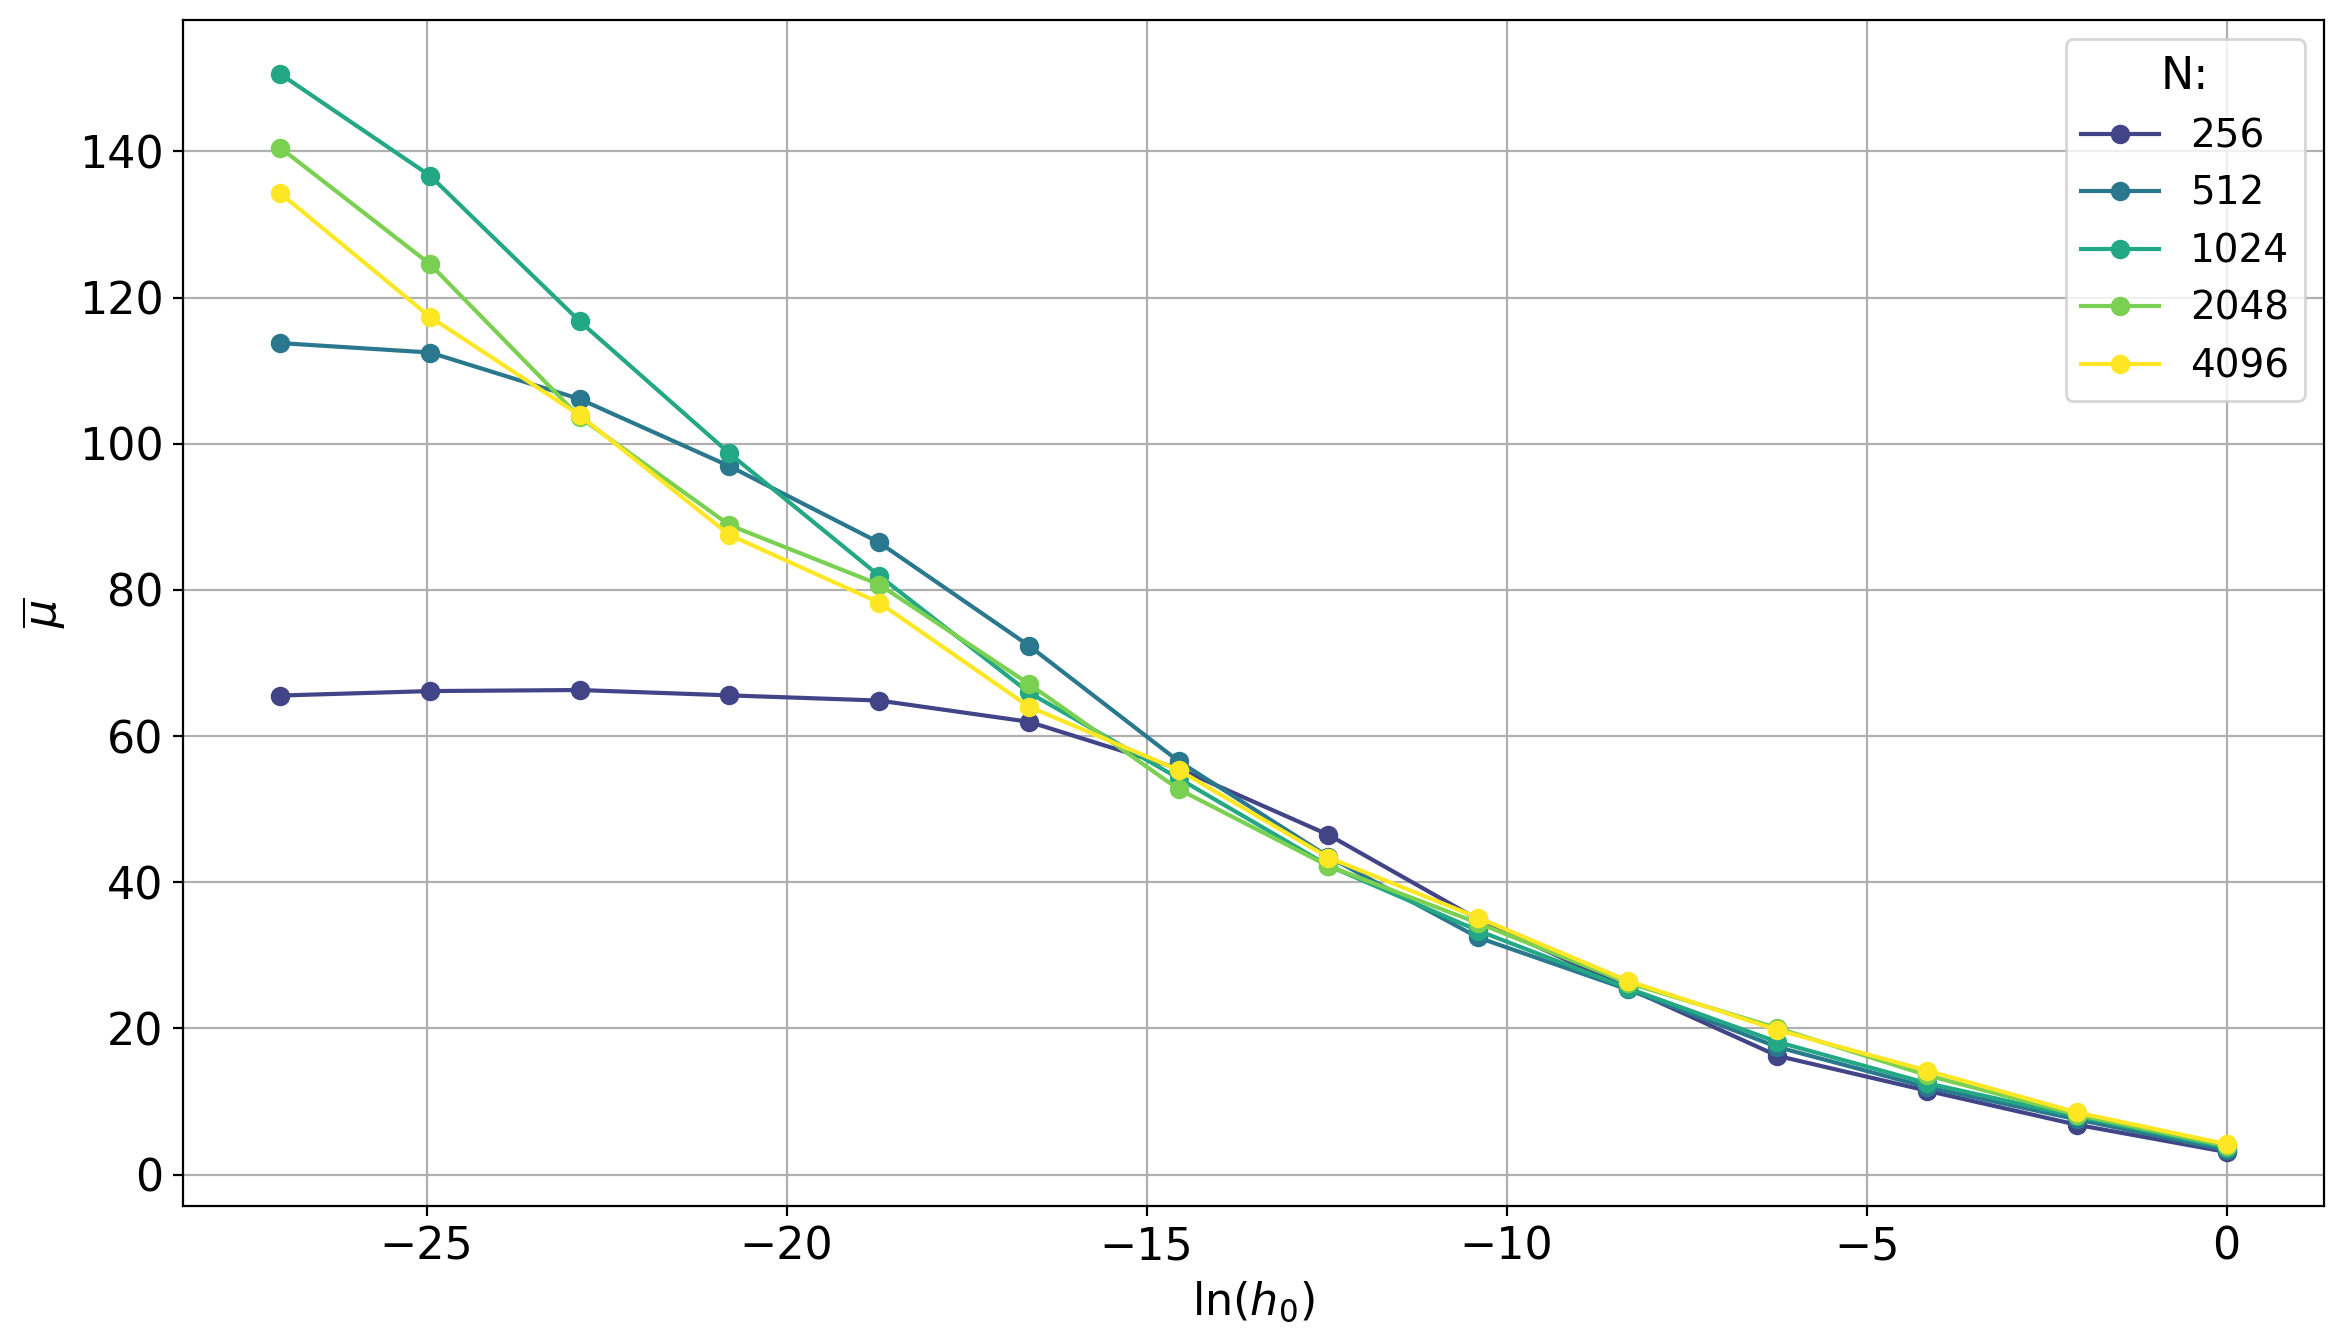

In [44]:
results = read_final_values("mm_at_gamma0C")
plot_analysics_at_critical_point(results, log_abs=False, ylabel=r"$\overline{\mu}$")